# 03 Section Extraction

## Goal

This notebook extracts important SEC 10-K sections from the cleaned filing text.

Instead of giving the RAG system one massive document, we will split each filing into meaningful business sections.

Important 10-K sections:

| Section | Meaning |
|---|---|
| Item 1 | Business overview |
| Item 1A | Risk factors |
| Item 7 | Management Discussion and Analysis |
| Item 7A | Market risk |
| Item 8 | Financial statements |

The main output will be a structured section-level dataset.

In [1]:
# Import tools for working with files and folders
from pathlib import Path

# Import pandas for tabular data work
import pandas as pd

# Import regular expressions for detecting SEC item headers
import re

# Import matplotlib for charts
import matplotlib.pyplot as plt

In [2]:
# Detect the project root automatically
# If the notebook is running from the notebooks folder, go one level up
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Create main data paths
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

# Folder that contains clean SEC text files from notebook 02
CLEAN_TEXT_DIR = PROCESSED_DIR / "clean_sec_text"

# Folder where section extraction outputs will be saved
SECTION_DIR = PROCESSED_DIR / "sec_sections"
SECTION_DIR.mkdir(parents=True, exist_ok=True)

# Print paths so we can verify everything is correct
print("Project root:", PROJECT_ROOT)
print("Clean SEC text folder:", CLEAN_TEXT_DIR)
print("Section output folder:", SECTION_DIR)

Project root: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI
Clean SEC text folder: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\clean_sec_text
Section output folder: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_sections


In [3]:
# Set path to clean filing metadata from notebook 02
clean_metadata_file = PROCESSED_DIR / "clean_sec_filing_metadata.csv"

# Check that the file exists before loading it
if not clean_metadata_file.exists():
    raise FileNotFoundError(
        f"Could not find {clean_metadata_file}. Run 02_data_understanding_and_eda.ipynb first."
    )

# Load clean filing metadata
clean_filings_df = pd.read_csv(clean_metadata_file)

# Preview the metadata
clean_filings_df

,ticker,company_name,filing_date,accession_number,raw_character_count,clean_character_count,clean_word_count,raw_file,clean_file
0,AAPL,Apple,2025-10-31,0000320193-25-000079,1520208,220566,32213,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
1,AMD,Advanced Micro Devices,2026-02-04,0000002488-26-000018,2174592,425188,61758,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
2,MSFT,Microsoft,2025-07-30,0000950170-25-100235,8158067,347391,49356,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
3,NVDA,NVIDIA,2026-02-25,0001045810-26-000021,1967816,360422,53068,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
4,TSLA,Tesla,2026-01-29,0001628280-26-003952,2391529,429673,62155,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...


In [4]:
# Set path to the original download log from notebook 01
download_log_file = PROJECT_ROOT / "data" / "raw" / "sec_metadata" / "starter_company_10k_download_log.csv"

# Check whether the download log exists
if download_log_file.exists():

    # Load the download log from notebook 01
    download_log = pd.read_csv(download_log_file)

    # Keep only the columns needed for citation metadata
    filing_url_lookup = download_log[
        ["accession_number", "filing_url"]
    ].drop_duplicates()

    # Merge filing URLs into the clean filing metadata
    clean_filings_df = clean_filings_df.merge(
        filing_url_lookup,
        on="accession_number",
        how="left"
    )

# If the download log is missing, create an empty filing_url column
else:
    clean_filings_df["filing_url"] = None

# Preview the clean filing metadata with filing URLs included
clean_filings_df.head()

,ticker,company_name,filing_date,accession_number,raw_character_count,clean_character_count,clean_word_count,raw_file,clean_file,filing_url
0,AAPL,Apple,2025-10-31,0000320193-25-000079,1520208,220566,32213,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,https://www.sec.gov/Archives/edgar/data/320193...
1,AMD,Advanced Micro Devices,2026-02-04,0000002488-26-000018,2174592,425188,61758,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,https://www.sec.gov/Archives/edgar/data/2488/0...
2,MSFT,Microsoft,2025-07-30,0000950170-25-100235,8158067,347391,49356,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,https://www.sec.gov/Archives/edgar/data/789019...
3,NVDA,NVIDIA,2026-02-25,0001045810-26-000021,1967816,360422,53068,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,https://www.sec.gov/Archives/edgar/data/104581...
4,TSLA,Tesla,2026-01-29,0001628280-26-003952,2391529,429673,62155,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,https://www.sec.gov/Archives/edgar/data/131860...


In [5]:
# Select the first clean filing as a sample
sample_row = clean_filings_df.iloc[0]

# Get the clean text file path
sample_file = Path(sample_row["clean_file"])

# Read the clean filing text
sample_text = sample_file.read_text(encoding="utf-8")

# Print basic information
print("Ticker:", sample_row["ticker"])
print("Company:", sample_row["company_name"])
print("File:", sample_file.name)
print("Characters:", len(sample_text))
print("Words:", len(sample_text.split()))

# Preview the first 2,000 characters
print(sample_text[:2000])

Ticker: AAPL
Company: Apple
File: AAPL_2025-10-31_10K_clean.txt
Characters: 220566
Words: 32213
aapl-20250927 false 2025 FY 0000320193 P1Y P1Y P1Y P1Y http://fasb.org/us-gaap/2025#LongTermDebtNoncurrent http://fasb.org/us-gaap/2025#LongTermDebtNoncurrent http://fasb.org/us-gaap/2025#OtherAssetsNoncurrent http://fasb.org/us-gaap/2025#OtherAssetsNoncurrent http://fasb.org/us-gaap/2025#PropertyPlantAndEquipmentNet http://fasb.org/us-gaap/2025#PropertyPlantAndEquipmentNet http://fasb.org/us-gaap/2025#OtherLiabilitiesCurrent http://fasb.org/us-gaap/2025#OtherLiabilitiesCurrent http://fasb.org/us-gaap/2025#OtherLiabilitiesNoncurrent http://fasb.org/us-gaap/2025#OtherLiabilitiesNoncurrent http://fasb.org/us-gaap/2025#OtherLiabilitiesCurrent http://fasb.org/us-gaap/2025#OtherLiabilitiesCurrent http://fasb.org/us-gaap/2025#OtherLiabilitiesNoncurrent http://fasb.org/us-gaap/2025#OtherLiabilitiesNoncurrent iso4217:USD xbrli:shares iso4217:USD xbrli:shares xbrli:pure aapl:Customer aapl:Vendor aapl

In [6]:
def normalize_sec_text(text):
    """
    Normalize SEC filing text so item headers are easier to detect.
    """

    # Replace non-breaking spaces with normal spaces
    text = text.replace("\xa0", " ")

    # Replace fancy dashes with normal dashes
    text = text.replace("—", "-").replace("–", "-")

    # Collapse repeated whitespace into a single space
    text = re.sub(r"\s+", " ", text)

    # Strip leading and trailing whitespace
    text = text.strip()

    # Return cleaned text
    return text

In [7]:
# Define the SEC sections we want to extract
# Each section has a start item and an ending item
section_targets = {
    "item_1_business": {
        "start_item": "1",
        "end_items": ["1A"]
    },
    "item_1a_risk_factors": {
        "start_item": "1A",
        "end_items": ["1B"]
    },
    "item_7_mda": {
        "start_item": "7",
        "end_items": ["7A", "8"]
    },
    "item_7a_market_risk": {
        "start_item": "7A",
        "end_items": ["8"]
    }
}

# Display section targets
section_targets

{'item_1_business': {'start_item': '1', 'end_items': ['1A']},
 'item_1a_risk_factors': {'start_item': '1A', 'end_items': ['1B']},
 'item_7_mda': {'start_item': '7', 'end_items': ['7A', '8']},
 'item_7a_market_risk': {'start_item': '7A', 'end_items': ['8']}}

In [8]:
def build_item_pattern(item_code):
    """
    Build a regex pattern for an SEC item header.
    """

    # Escape the item code so values like 1A or 7A are handled safely
    escaped_item = re.escape(item_code)

    # Match patterns like:
    # Item 1A.
    # ITEM 1A:
    # Item 7 -
    # Item 7A Quantitative and Qualitative Disclosures
    pattern = rf"\bitem\s+{escaped_item}\b[\.\:\-\s]*"

    # Return compiled regex pattern using case-insensitive matching
    return re.compile(pattern, re.IGNORECASE)

In [9]:
def find_item_positions(text, item_code):
    """
    Find all positions where a specific SEC item header appears.
    """

    # Build the regex pattern for this item code
    pattern = build_item_pattern(item_code)

    # Find all matches in the filing text
    matches = list(pattern.finditer(text))

    # Convert matches into a list of dictionaries
    positions = []

    for match in matches:

        # Save the start position, end position, and matched text
        positions.append({
            "item_code": item_code,
            "start": match.start(),
            "end": match.end(),
            "match_text": match.group()
        })

    # Return all header positions
    return positions

In [10]:
# Normalize the sample filing text
sample_text_normalized = normalize_sec_text(sample_text)

# Test item header detection for common 10-K sections
test_items = ["1", "1A", "1B", "7", "7A", "8"]

# Store detection results
header_detection_results = []

for item in test_items:

    # Find header positions for this item
    positions = find_item_positions(sample_text_normalized, item)

    # Store result summary
    header_detection_results.append({
        "item": item,
        "match_count": len(positions),
        "first_position": positions[0]["start"] if positions else None
    })

# Convert results to DataFrame
header_detection_df = pd.DataFrame(header_detection_results)

# Display detection results
header_detection_df

,item,match_count,first_position
0,1,3,19091
1,1A,5,19110
2,1B,2,19134
3,7,5,19434
4,7A,2,19531
5,8,8,19602


In [11]:
# Create an empty list to store header previews
header_previews = []

# Loop through target item codes
for item in test_items:

    # Find all positions for the item
    positions = find_item_positions(sample_text_normalized, item)

    # Keep first 5 matches for preview
    for pos in positions[:5]:

        # Get text around the detected header
        preview_start = max(pos["start"] - 80, 0)
        preview_end = min(pos["start"] + 220, len(sample_text_normalized))

        # Store preview record
        header_previews.append({
            "item": item,
            "position": pos["start"],
            "preview": sample_text_normalized[preview_start:preview_end]
        })

# Convert previews to DataFrame
header_previews_df = pd.DataFrame(header_previews)

# Display header previews
header_previews_df

,item,position,preview
0,1,19091,"10-K For the Fiscal Year Ended September 27, 2..."
1,1,20607,nd uncertainties. Many of the forward-looking ...
2,1,22370,o Apple Inc. and its wholly owned subsidiaries...
3,1A,19110,"Year Ended September 27, 2025 TABLE OF CONTEN..."
4,1A,21731,"se such differences include, but are not limit..."
5,1A,38421,ntended to be inactive textual references only...
6,1A,109149,appropriate. For a discussion of the Company’s...
7,1A,125611,gross margins can be impacted by a variety of...
8,1B,19134,", 2025 TABLE OF CONTENTS Page Part I Item 1. B..."
9,1B,106466,d have a material adverse impact on investor c...


In [12]:
# Define title hints for each SEC item
# These hints help the extractor avoid false matches from table of contents or cross-references
section_title_hints = {
    "1": ["business"],
    "1A": ["risk factors"],
    "7": [
        "management's discussion",
        "management discussion",
        "financial condition",
        "results of operations"
    ],
    "7A": [
        "quantitative and qualitative",
        "market risk"
    ]
}


def score_section_start(section_text, start_item):
    """
    Score whether a section start looks like the real SEC section header.
    Higher score means the candidate is more likely to be the true section.
    """

    # Look at the beginning of the candidate section
    preview = section_text[:500].lower()

    # Start score at zero
    score = 0

    # Escape the item code for regex safety
    escaped_item = re.escape(start_item)

    # Reward candidates that begin directly with the expected item header
    if re.match(rf"^item\s+{escaped_item}\b", preview, flags=re.IGNORECASE):
        score += 10

    # Reward candidates that include the expected section title near the beginning
    for hint in section_title_hints.get(start_item, []):
        if hint in preview:
            score += 20

    # Penalize table of contents matches
    if "table of contents" in preview:
        score -= 30

    # Penalize cross-reference language
    if "of this form 10-k" in preview:
        score -= 15

    # Penalize inactive XBRL reference language
    if "inactive textual references" in preview:
        score -= 30

    # Return final score
    return score


def extract_best_section(text, start_item, end_items, min_chars=1000):
    """
    Extract the best matching SEC section.

    SEC filings often mention item headers in the table of contents, cross-references,
    or XBRL metadata. This function scores candidates and keeps the best section.
    """

    # Normalize text before extraction
    text = normalize_sec_text(text)

    # Find all possible start positions for the target section
    start_positions = find_item_positions(text, start_item)

    # Create a list to store candidate sections
    candidates = []

    # Loop through each possible start position
    for start_pos in start_positions:

        # Get the start index of this candidate section
        section_start = start_pos["start"]

        # Create a list to store possible ending positions
        possible_end_positions = []

        # Loop through possible ending item codes
        for end_item in end_items:

            # Find all positions for the ending item
            end_positions = find_item_positions(text, end_item)

            # Keep only ending positions that appear after the start position
            valid_end_positions = [
                pos["start"] for pos in end_positions
                if pos["start"] > section_start
            ]

            # Add valid ending positions to the list
            possible_end_positions.extend(valid_end_positions)

        # Skip this candidate if no ending item was found after it
        if not possible_end_positions:
            continue

        # Use the closest ending item after the start
        section_end = min(possible_end_positions)

        # Extract candidate section text
        section_text = text[section_start:section_end].strip()

        # Measure candidate section length
        section_length = len(section_text)

        # Skip candidates that are too short to be real sections
        if section_length < min_chars:
            continue

        # Score the quality of this section start
        start_score = score_section_start(section_text, start_item)

        # Store candidate section details
        candidates.append({
            "section_text": section_text,
            "start_position": section_start,
            "end_position": section_end,
            "character_count": section_length,
            "word_count": len(section_text.split()),
            "start_score": start_score,
            "preview": section_text[:300]
        })

    # Return None if no valid candidates were found
    if not candidates:
        return None

    # Sort by start quality first, then section length
    best_candidate = sorted(
        candidates,
        key=lambda x: (x["start_score"], x["character_count"]),
        reverse=True
    )[0]

    # Return the best section candidate
    return best_candidate

In [13]:
# Create an empty list to store extracted sample sections
sample_sections = []

# Loop through each target section
for section_name, config in section_targets.items():

    # Extract the best section from the sample filing
    section_result = extract_best_section(
        text=sample_text,
        start_item=config["start_item"],
        end_items=config["end_items"],
        min_chars=1000
    )

    # If section was found, store the result
    if section_result is not None:
        sample_sections.append({
            "ticker": sample_row["ticker"],
            "company_name": sample_row["company_name"],
            "section_name": section_name,
            "start_item": config["start_item"],
            "end_items": ", ".join(config["end_items"]),
            "character_count": section_result["character_count"],
            "word_count": section_result["word_count"],
            "start_position": section_result["start_position"],
            "end_position": section_result["end_position"],
            "section_preview": section_result["section_text"][:500]
        })

    # If section was not found, store a missing record
    else:
        sample_sections.append({
            "ticker": sample_row["ticker"],
            "company_name": sample_row["company_name"],
            "section_name": section_name,
            "start_item": config["start_item"],
            "end_items": ", ".join(config["end_items"]),
            "character_count": 0,
            "word_count": 0,
            "start_position": None,
            "end_position": None,
            "section_preview": "SECTION NOT FOUND"
        })

# Convert sample section results to DataFrame
sample_sections_df = pd.DataFrame(sample_sections)

# Display sample extraction results
sample_sections_df

,ticker,company_name,section_name,start_item,end_items,character_count,word_count,start_position,end_position,section_preview
0,AAPL,Apple,item_1_business,1,1A,16050,2380,22370,38421,Item 1. Business Company Background The Compan...
1,AAPL,Apple,item_1a_risk_factors,1A,1B,68044,9784,38421,106466,Item 1A. Risk Factors The following summarizes...
2,AAPL,Apple,item_7_mda,7,"7A, 8",18710,2773,20674,39385,Item 7 of this Form 10-K under the heading “Ma...
3,AAPL,Apple,item_7a_market_risk,7A,8,3020,460,135942,138963,Item 7A. Quantitative and Qualitative Disclosu...


In [14]:
# Create an empty list to store all extracted section records
all_section_records = []

# Loop through each clean filing
for _, row in clean_filings_df.iterrows():

    # Get basic filing metadata
    ticker = row["ticker"]
    company_name = row["company_name"]
    filing_date = row["filing_date"]
    accession_number = row["accession_number"]
    filing_url = row.get("filing_url", None)
    clean_file = Path(row["clean_file"])

    # Read the clean filing text
    filing_text = clean_file.read_text(encoding="utf-8")

    # Loop through each target SEC section
    for section_name, config in section_targets.items():

        # Extract the best matching section
        section_result = extract_best_section(
            text=filing_text,
            start_item=config["start_item"],
            end_items=config["end_items"],
            min_chars=1000
        )

        # If section was found, save the section text as a separate file
        if section_result is not None:

            # Create section text file name
            section_file_name = f"{ticker}_{filing_date}_{section_name}.txt"

            # Create full section file path
            section_file_path = SECTION_DIR / section_file_name

            # Save section text locally
            section_file_path.write_text(
                section_result["section_text"],
                encoding="utf-8"
            )

            # Store section metadata
            all_section_records.append({
                "ticker": ticker,
                "company_name": company_name,
                "filing_date": filing_date,
                "accession_number": accession_number,
                "filing_url": filing_url,
                "section_name": section_name,
                "start_item": config["start_item"],
                "end_items": ", ".join(config["end_items"]),
                "section_found": True,
                "character_count": section_result["character_count"],
                "word_count": section_result["word_count"],
                "start_position": section_result["start_position"],
                "end_position": section_result["end_position"],
                "start_score": section_result["start_score"],
                "section_file": str(section_file_path)
            })

        # If section was not found, save a missing-section record
        else:

            # Store missing section metadata
            all_section_records.append({
                "ticker": ticker,
                "company_name": company_name,
                "filing_date": filing_date,
                "accession_number": accession_number,
                "filing_url": filing_url,
                "section_name": section_name,
                "start_item": config["start_item"],
                "end_items": ", ".join(config["end_items"]),
                "section_found": False,
                "character_count": 0,
                "word_count": 0,
                "start_position": None,
                "end_position": None,
                "start_score": None,
                "section_file": None
            })

# Convert extracted section records into a DataFrame
sections_df = pd.DataFrame(all_section_records)

# Display the section extraction results
sections_df

,ticker,company_name,filing_date,accession_number,filing_url,section_name,start_item,end_items,section_found,character_count,word_count,start_position,end_position,start_score,section_file
0,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_1_business,1,1A,True,16050,2380,22370,38421,30,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
1,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_1a_risk_factors,1A,1B,True,68044,9784,38421,106466,30,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
2,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_7_mda,7,"7A, 8",True,18710,2773,20674,39385,35,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
3,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_7a_market_risk,7A,8,True,3020,460,135942,138963,50,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
4,AMD,Advanced Micro Devices,2026-02-04,0000002488-26-000018,https://www.sec.gov/Archives/edgar/data/2488/0...,item_1_business,1,1A,True,3275,468,39031,42307,30,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
5,AMD,Advanced Micro Devices,2026-02-04,0000002488-26-000018,https://www.sec.gov/Archives/edgar/data/2488/0...,item_1a_risk_factors,1A,1B,True,188359,28171,42307,230667,30,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
6,AMD,Advanced Micro Devices,2026-02-04,0000002488-26-000018,https://www.sec.gov/Archives/edgar/data/2488/0...,item_7_mda,7,"7A, 8",True,194597,29043,42390,236988,50,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
7,AMD,Advanced Micro Devices,2026-02-04,0000002488-26-000018,https://www.sec.gov/Archives/edgar/data/2488/0...,item_7a_market_risk,7A,8,True,4947,751,277060,282008,50,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
8,MSFT,Microsoft,2025-07-30,0000950170-25-100235,https://www.sec.gov/Archives/edgar/data/789019...,item_1_business,1,1A,True,42033,5892,41373,83407,30,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
9,MSFT,Microsoft,2025-07-30,0000950170-25-100235,https://www.sec.gov/Archives/edgar/data/789019...,item_1a_risk_factors,1A,1B,True,68963,10118,90032,158996,10,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...


#### Check Section Extraction Success

In [15]:
# Count found and missing sections
section_success_summary = (
    sections_df
    .groupby(["section_name", "section_found"])
    .size()
    .reset_index(name="count")
)

# Display success summary
section_success_summary

,section_name,section_found,count
0,item_1_business,True,5
1,item_1a_risk_factors,True,5
2,item_7_mda,True,5
3,item_7a_market_risk,True,5


In [16]:
# Set output path for section metadata
sections_metadata_file = PROCESSED_DIR / "sec_10k_sections_metadata.csv"

# Save section metadata to CSV
sections_df.to_csv(sections_metadata_file, index=False)

# Confirm file was saved
print("Saved section metadata to:", sections_metadata_file)

Saved section metadata to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_10k_sections_metadata.csv


#### Load Section Text Preview

In [17]:
# Filter to only sections that were successfully found
found_sections = sections_df[sections_df["section_found"] == True].copy()

# Select one section for preview
preview_section_row = found_sections.iloc[0]

# Read section text from file
preview_section_text = Path(preview_section_row["section_file"]).read_text(encoding="utf-8")

# Print section information
print("Ticker:", preview_section_row["ticker"])
print("Section:", preview_section_row["section_name"])
print("Characters:", len(preview_section_text))
print("Words:", len(preview_section_text.split()))

# Preview first 2,000 characters
print(preview_section_text[:2000])

Ticker: AAPL
Section: item_1_business
Characters: 16050
Words: 2380
Item 1. Business Company Background The Company designs, manufactures and markets smartphones, personal computers, tablets, wearables and accessories, and sells a variety of related services. The Company’s fiscal year is the 52- or 53-week period that ends on the last Saturday of September. Products iPhone iPhone ® is the Company’s line of smartphones based on its iOS operating system. The iPhone line includes iPhone 17 Pro, iPhone Air™, iPhone 17, iPhone 16 and iPhone 16e. Mac Mac ® is the Company’s line of personal computers based on its macOS ® operating system. The Mac line includes laptops MacBook Air ® and MacBook Pro ® , as well as desktops iMac ® , Mac mini ® , Mac Studio ® and Mac Pro ® . iPad iPad ® is the Company’s line of multipurpose tablets based on its iPadOS ® operating system. The iPad line includes iPad Pro ® , iPad Air ® , iPad and iPad mini ® . Wearables, Home and Accessories Wearables includes smar

In [18]:
# Create summary statistics for section word counts
section_length_summary = (
    found_sections
    .groupby("section_name")["word_count"]
    .agg(["count", "mean", "min", "max"])
    .reset_index()
)

# Round average word count for readability
section_length_summary["mean"] = section_length_summary["mean"].round(0)

# Display section length summary
section_length_summary

,section_name,count,mean,min,max
0,item_1_business,5,4250.0,468,6553
1,item_1a_risk_factors,5,15814.0,9784,28171
2,item_7_mda,5,7801.0,834,29043
3,item_7a_market_risk,5,481.0,254,751


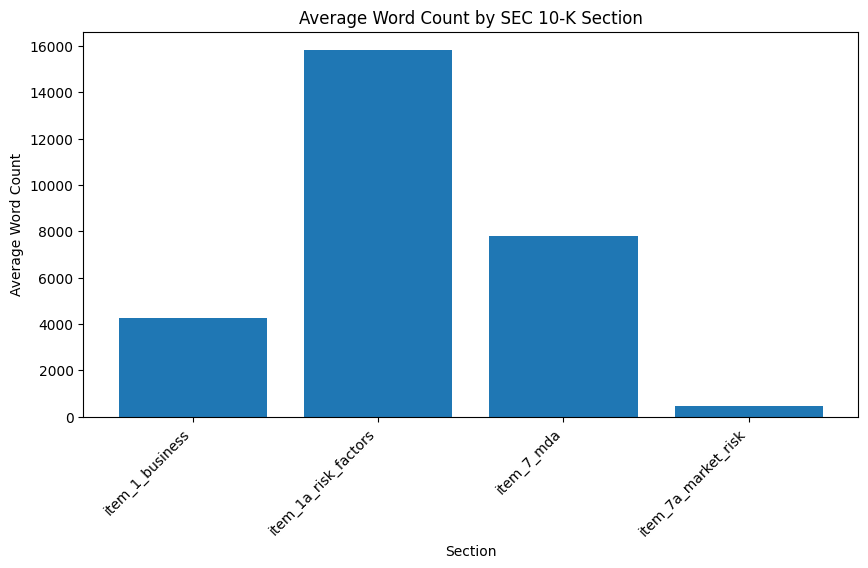

In [19]:
# Create a bar chart of average word count by section
plt.figure(figsize=(10, 5))

# Plot average word count
plt.bar(
    section_length_summary["section_name"],
    section_length_summary["mean"]
)

# Add chart title and labels
plt.title("Average Word Count by SEC 10-K Section")
plt.xlabel("Section")
plt.ylabel("Average Word Count")

# Rotate labels for readability
plt.xticks(rotation=45, ha="right")

# Display chart
plt.show()

In [20]:
# Create a pivot table of word counts by company and section
section_size_pivot = found_sections.pivot_table(
    index="ticker",
    columns="section_name",
    values="word_count",
    aggfunc="sum"
).fillna(0)

# Display pivot table
section_size_pivot

section_name,item_1_business,item_1a_risk_factors,item_7_mda,item_7a_market_risk
ticker,,,,
AAPL,2380,9784,2773,460
AMD,468,28171,29043,751
MSFT,5892,10118,1105,278
NVDA,5955,18339,5252,661
TSLA,6553,12658,834,254


In [21]:
# Set output path for section size pivot table
section_size_pivot_file = PROCESSED_DIR / "sec_10k_section_size_pivot.csv"

# Save section size pivot table
section_size_pivot.to_csv(section_size_pivot_file)

# Confirm file was saved
print("Saved section size pivot to:", section_size_pivot_file)

Saved section size pivot to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_10k_section_size_pivot.csv


In [22]:
# Create a list to hold RAG-ready section records
rag_section_records = []

# Loop through only successfully extracted sections
for _, row in found_sections.iterrows():

    # Read section text from file
    section_text = Path(row["section_file"]).read_text(encoding="utf-8")

    # Create a readable source label for citations
    source_label = (
        f"{row['ticker']} {row['filing_date']} 10-K "
        f"{row['section_name']}"
    )

    # Store RAG-ready section record
    rag_section_records.append({
        "document_id": f"{row['ticker']}_{row['filing_date']}_{row['section_name']}",
        "ticker": row["ticker"],
        "company_name": row["company_name"],
        "filing_date": row["filing_date"],
        "accession_number": row["accession_number"],
        "filing_url": row.get("filing_url", None),
        "section_name": row["section_name"],
        "source_label": source_label,
        "text": section_text,
        "character_count": len(section_text),
        "word_count": len(section_text.split())
    })

# Convert RAG-ready records to DataFrame
rag_sections_df = pd.DataFrame(rag_section_records)

# Display RAG-ready section dataset
rag_sections_df.head()

,document_id,ticker,company_name,filing_date,accession_number,filing_url,section_name,source_label,text,character_count,word_count
0,AAPL_2025-10-31_item_1_business,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_1_business,AAPL 2025-10-31 10-K item_1_business,Item 1. Business Company Background The Compan...,16050,2380
1,AAPL_2025-10-31_item_1a_risk_factors,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_1a_risk_factors,AAPL 2025-10-31 10-K item_1a_risk_factors,Item 1A. Risk Factors The following summarizes...,68044,9784
2,AAPL_2025-10-31_item_7_mda,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_7_mda,AAPL 2025-10-31 10-K item_7_mda,Item 7 of this Form 10-K under the heading “Ma...,18710,2773
3,AAPL_2025-10-31_item_7a_market_risk,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_7a_market_risk,AAPL 2025-10-31 10-K item_7a_market_risk,Item 7A. Quantitative and Qualitative Disclosu...,3020,460
4,AMD_2026-02-04_item_1_business,AMD,Advanced Micro Devices,2026-02-04,0000002488-26-000018,https://www.sec.gov/Archives/edgar/data/2488/0...,item_1_business,AMD 2026-02-04 10-K item_1_business,ITEM 1. BUSINESS Cautionary Statement Regardin...,3275,468


In [23]:
# Set output path for RAG-ready section dataset
rag_sections_file = PROCESSED_DIR / "sec_10k_rag_sections.csv"

# Save RAG-ready section dataset
rag_sections_df.to_csv(rag_sections_file, index=False)

# Confirm file was saved
print("Saved RAG-ready section dataset to:", rag_sections_file)

Saved RAG-ready section dataset to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_10k_rag_sections.csv


In [24]:
# Create final checkpoint table
section_checkpoint = pd.DataFrame({
    "output": [
        "Section text folder",
        "Section metadata CSV",
        "Section size pivot CSV",
        "RAG-ready section dataset"
    ],
    "path": [
        str(SECTION_DIR),
        str(sections_metadata_file),
        str(section_size_pivot_file),
        str(rag_sections_file)
    ],
    "exists": [
        SECTION_DIR.exists(),
        sections_metadata_file.exists(),
        section_size_pivot_file.exists(),
        rag_sections_file.exists()
    ]
})

# Display checkpoint table
section_checkpoint

,output,path,exists
0,Section text folder,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
1,Section metadata CSV,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
2,Section size pivot CSV,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
3,RAG-ready section dataset,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True


In [25]:
# Confirm the RAG-ready section dataset has citation URLs
rag_sections_df[
    [
        "ticker",
        "section_name",
        "word_count",
        "filing_url"
    ]
].head()

,ticker,section_name,word_count,filing_url
0,AAPL,item_1_business,2380,https://www.sec.gov/Archives/edgar/data/320193...
1,AAPL,item_1a_risk_factors,9784,https://www.sec.gov/Archives/edgar/data/320193...
2,AAPL,item_7_mda,2773,https://www.sec.gov/Archives/edgar/data/320193...
3,AAPL,item_7a_market_risk,460,https://www.sec.gov/Archives/edgar/data/320193...
4,AMD,item_1_business,468,https://www.sec.gov/Archives/edgar/data/2488/0...


## Section Extraction Conclusion

This notebook converted full clean 10-K filings into structured section-level documents.

The project now has:

```text
Clean filing text
→ Item 1 Business
→ Item 1A Risk Factors
→ Item 7 Management Discussion and Analysis
→ Item 7A Market Risk
→ RAG-ready section dataset